# Baumdaten fürs Klimadashboard

Aktuell: Sehr grobe Annäherung der Werte durch pauschale Faktoren!


In [ ]:
# Fehlende Pakete installieren, ggf. einkommentieren und ausführen

#!python -m pip install geopandas
#!python -m pip install pandas
#!python -m pip install matplotlib
#!python -m pip install dotenv
#!python -m pip install requests

In [5]:
import requests
import xml.etree.ElementTree as ET

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from pprint import pprint
import json
import os 

# Place .env file in the same directory as this script and add the following lines:
# WFS_URL=https://your-wfs-url
# USER=api-username
# PASSWORD=api-password
# PROXY=http://your-proxy-url:port (optional)

load_dotenv()
WFS_URL = os.getenv("WFS_URL")
USER = os.getenv("USER")
PASSWORD = os.getenv("PASSWORD")
PROXY = os.getenv("PROXY")
proxies = {"http": PROXY, "https": PROXY} if PROXY else False

if not WFS_URL:
    print("Fehler: WFS_URL ist nicht gesetzt.")
if not USER:
    print("Fehler: USER ist nicht gesetzt.")
if not PASSWORD:
    print("Fehler: PASSWORD ist nicht gesetzt.")

CURRENT_YEAR = pd.Timestamp.now().year
GEOJSON_FILE = "data/feature_data.geojson"
layer_name = "tree:stamuenster_point"

params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typeNames": layer_name,
    "outputFormat": "application/json",
}

if not os.path.exists("data"):
  os.mkdir("data")
  print("Folder 'data' created!")

if os.path.exists(GEOJSON_FILE):
    print(f"Datei '{GEOJSON_FILE}' existiert bereits.")
else:
    print(f"Datei wird gespeichert als: {GEOJSON_FILE}")
 
    session = requests.Session()
    session.auth = (USER, PASSWORD)
    response = session.get(WFS_URL, params=params, proxies=proxies)

    with open(GEOJSON_FILE, "w") as f:
        json.dump(response.json(), f)

# echo filesize of geojson file in megabytes
print(f"Größe der GeoJSON-Datei: {os.path.getsize(GEOJSON_FILE) / (1024 * 1024):.2f} MB")
gdf_orig = gpd.read_file(GEOJSON_FILE)
print("Spalten: ", gdf_orig.columns)


Folder 'data' created!
Datei wird gespeichert als: data/feature_data.geojson
Größe der GeoJSON-Datei: 128.17 MB
Spalten:  Index(['id', 'uuid', 'baumnummer', 'plakette', 'artbotanisch', 'artdeutsch',
       'pflanzjahr', 'kronendurchmesser', 'hoehe', 'durchmesser', 'umfang',
       'vitalitaet', 'entwicklungsphase', 'kronenform', 'artenschutz',
       'sicherheitserwartung', 'bewertungkrone', 'bewertungstamm',
       'bewertungwurzel', 'sonstiges', 'verkehrssicherheit', 'massnahmeanzahl',
       'massnahmefrist', 'datumnaechstekontrolle', 'bearbeiter',
       'datumbearbeitung', 'nutzerkontrolle', 'datumletzekontrolle',
       'geometry'],
      dtype='object')


# Ausreisser entfernen

In [6]:

CHECK_FIELD = "kronendurchmesser"

print("Kronendurchmesser über 50 Meter herausfiltern")
ausreisser = gdf_orig[gdf_orig["kronendurchmesser"] > 50]
ausreisser = ausreisser.sort_values(by=CHECK_FIELD, ascending=False)
print("So viele Ausreißer rausgefiltert: ")
print(ausreisser[["artdeutsch", CHECK_FIELD]].shape[0])
print ("und zwar:")      
print(ausreisser[["artdeutsch", CHECK_FIELD]])

gdf = gdf_orig.drop(ausreisser.index)

Kronendurchmesser über 50 Meter herausfiltern
So viele Ausreißer rausgefiltert: 
46
und zwar:
                        artdeutsch  kronendurchmesser
34549                  Stiel-Eiche             4300.0
12935           Rot-, Schwarz-Erle             1833.0
48960                  Stiel-Eiche             1339.0
135315                    Rotbuche              714.0
59864                   Feld-Ahorn              414.0
138029            Weiss-/Sandbirke              123.0
128509                 Stiel-Eiche              120.0
105694               Silber-Pappel              115.0
71447                    Hainbuche              115.0
136894           Gewöhnliche Esche              115.0
91530                     Rotbuche              114.0
22804                  Stiel-Eiche              114.0
118218         Gewöhnliche Platane              114.0
81330                  Stiel-Eiche              113.0
128455                 Stiel-Eiche              113.0
68182                  Stiel-Eiche        

# Alter der Bäume in Klassen aufteilen

pflanzjahr
[0, 15)        7136
[15, 40)      61037
[40, 60)      35582
[60, 80)      12308
[80, 100)      5476
[100, 225)     3814
Name: count, dtype: int64


Text(0.5, 1.0, 'Alter der Bäume (20-Jahres-Kategorien) aus Pflanzjahr')

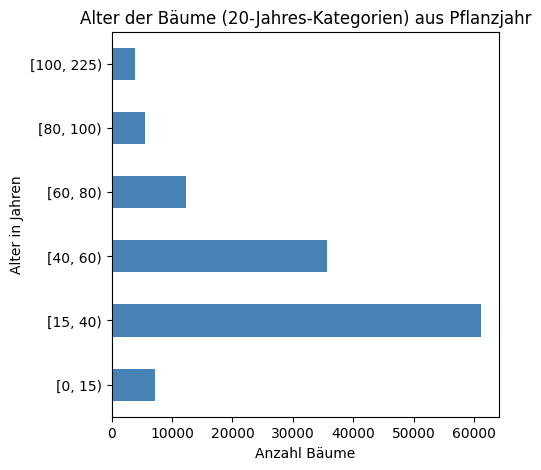

In [7]:
def add_labels(plt, x, y):
    for i in range(len(x)):
        plt.text(i, y[i] // 2, y[i], ha='center')  # Placing text slightly above the bar
        
current_year = pd.Timestamp.now().year

birth_year = pd.to_numeric(gdf["pflanzjahr"], errors="coerce")
birth_year = birth_year[birth_year.between(1800, current_year)]

ages = current_year - birth_year
max_age = int(ages.max())
if max_age <= 100:
    bins = [0, 15, 40, 60, 80, 100]
else:
    bins = [0, 15, 40, 60, 80, 100, max_age + 1]
age_categories = pd.cut(ages, bins=bins, right=False, include_lowest=True)
age_counts = age_categories.value_counts().sort_index()
print(age_counts)

fig, ax = plt.subplots(figsize=(5, 5))

age_counts.plot(kind="barh", ax=ax, color="steelblue")

ax.set_ylabel("Alter in Jahren")
ax.set_xlabel("Anzahl Bäume")
ax.set_title("Alter der Bäume (20-Jahres-Kategorien) aus Pflanzjahr")


# Berechnung der Werte fürs Klimadashboard

In [ ]:
import numpy as np
import pandas as pd

# Altersgruppendefinition fürs Klimadashboard
def altersgruppe(alter):
    if alter < 16:
        return "Jung"
    elif alter < 61:
        return "Mittel"
    else:
        return "Alt"

# Formel für: CO2 Bindung
def co2_rate(alter):
    if alter < 16:
        return 10   # kg/Jahr
    elif alter < 61:
        return 25
    else:
        return 40

gdf["alter"] = CURRENT_YEAR - gdf["pflanzjahr"]
pflanzungen = {}

# =========================== Berechnungen ===========================

# Kronenschirmfläche = Kreisfläche = π * r²
gdf["kronenschirmflaeche"] = np.pi * (gdf["kronendurchmesser"] / 2) ** 2

# CO2 Bindung in kg pro Jahr (Formel siehe Funktion co2_rate)
gdf["co2_kg_pro_jahr"] = gdf["alter"].apply(co2_rate)
# 32/12 * kg CO2 -> kg O2
# 748 -> Umrechnungsfaktor kg O2 in "Liter gasförmig, (1 bar, 15 °C)
gdf["o2_l_fluessig_pro_jahr"] = gdf["co2_kg_pro_jahr"] * (32 / 12) * 748

# Kühlleistung: 0.15 kW  pro m² Kronenschirmfläche
gdf["kuehlleistung_kw"] = gdf["kronenschirmflaeche"] * 0.15

def berechne_jahr(df, jahr):
    temp = df.copy()

    # Alter im betrachteten Jahr
    temp["alter"] = jahr - temp["pflanzjahr"]

    # Bäume, die damals noch nicht gepflanzt waren, ausblenden
    temp = temp[temp["alter"] >= 0]

    # Altersgruppen erstellen
    temp["gruppe"] = temp["alter"].apply(altersgruppe)

    # Hilfsfunktion, um die %-Werte für ein bestimmtes Feld zu berechnen und dem DataFrame hinzuzufügen
    def addFieldsToDataFrame(df, FIELD):
        erg = (
            temp.groupby("gruppe")[FIELD]
            .sum()
            .reindex(["Jung", "Mittel", "Alt"], fill_value=0)
        )
    
        gesamt = erg.sum()
        vals= erg.values
        percent = erg.values / gesamt * 100
        df["gruppe"] = erg.index
        df[f"{FIELD}"] = vals 
        df[f"{FIELD}_prozent"] = percent
        return df

    # Alle Werte des aktuellen Jahres zum DataFrame hinzufügen
    temp_df = pd.DataFrame()
    temp_df["jahr"] = jahr
    temp_df = addFieldsToDataFrame(temp_df, "kronenschirmflaeche")
    temp_df = addFieldsToDataFrame(temp_df, "co2_kg_pro_jahr")
    temp_df = addFieldsToDataFrame(temp_df, "o2_l_fluessig_pro_jahr")
    temp_df = addFieldsToDataFrame(temp_df, "kuehlleistung_kw")
    # TODO - Anzahl der Fällungen => hier gibt es noch eine Datenlieferung von 67
    # TODO: Pflanzungen pro Jahr => Alle Bäume mit Alter 0; #TODO diese Daten müssen noch richtig in die Tabelle pro Jahr (unabhängig von der Altersgruppe)
    pflanzungen[jahr] = (gdf["pflanzjahr"] == jahr).sum()
    print("Anzahl Pflanzungen im Jahr ", jahr, ": ",pflanzungen[jahr])
    return temp_df

startjahr = 2020
endjahr = CURRENT_YEAR

alle = []

for jahr in range(startjahr, endjahr + 1):
    t = berechne_jahr(gdf, jahr)
    t["jahr"] = jahr
    alle.append(t)

# Dataframe erstellen
slider_df = pd.concat(alle, ignore_index=True)

# Runden der Werte auf 2 Nachkommastellen, außer für die Spalten "jahr" und "gruppe"
cols = {col: 2 for col in slider_df.columns if col not in ("jahr", "gruppe")}
slider_df = slider_df.round(cols)

# Daten als CSV speichern
slider_df.to_csv("data/baumkachel_daten.csv", index=False)

# Daten ausgeben
slider_df


Anzahl Pflanzungen im Jahr  2020 :  336
Anzahl Pflanzungen im Jahr  2021 :  998
Anzahl Pflanzungen im Jahr  2022 :  207
Anzahl Pflanzungen im Jahr  2023 :  66
Anzahl Pflanzungen im Jahr  2024 :  138
Anzahl Pflanzungen im Jahr  2025 :  138
Anzahl Pflanzungen im Jahr  2026 :  62
{'kronenschirmflaeche': 2, 'kronenschirmflaeche_prozent': 2, 'co2_kg_pro_jahr': 2, 'co2_kg_pro_jahr_prozent': 2, 'o2_l_fluessig_pro_jahr': 2, 'o2_l_fluessig_pro_jahr_prozent': 2, 'kuehlleistung_kw': 2, 'kuehlleistung_kw_prozent': 2}


,jahr,gruppe,kronenschirmflaeche,kronenschirmflaeche_prozent,co2_kg_pro_jahr,co2_kg_pro_jahr_prozent,o2_l_fluessig_pro_jahr,o2_l_fluessig_pro_jahr_prozent,kuehlleistung_kw,kuehlleistung_kw_prozent
0,2020,Jung,372598.39,5.49,266925,8.02,5.324264e+08,8.02,55889.76,5.49
1,2020,Mittel,4629190.97,68.19,2449230,73.58,4.885397e+09,73.58,694378.65,68.19
2,2020,Alt,1786426.61,26.32,612680,18.41,1.222092e+09,18.41,267963.99,26.32
3,2021,Jung,332246.20,4.89,243130,7.28,4.849633e+08,7.28,49836.93,4.89
4,2021,Mittel,4640534.47,68.34,2471645,74.03,4.930108e+09,74.03,696080.17,68.34
5,2021,Alt,1817525.23,26.77,624040,18.69,1.244752e+09,18.69,272628.78,26.77
6,2022,Jung,298965.74,4.40,227925,6.82,4.546344e+08,6.82,44844.86,4.40
7,2022,Mittel,4663813.67,68.67,2485360,74.39,4.957465e+09,74.39,699572.05,68.67
8,2022,Alt,1829289.71,26.93,627600,18.79,1.251853e+09,18.79,274393.46,26.93
9,2023,Jung,259212.81,3.82,195585,5.85,3.901269e+08,5.85,38881.92,3.82


# Plotten der Werte 

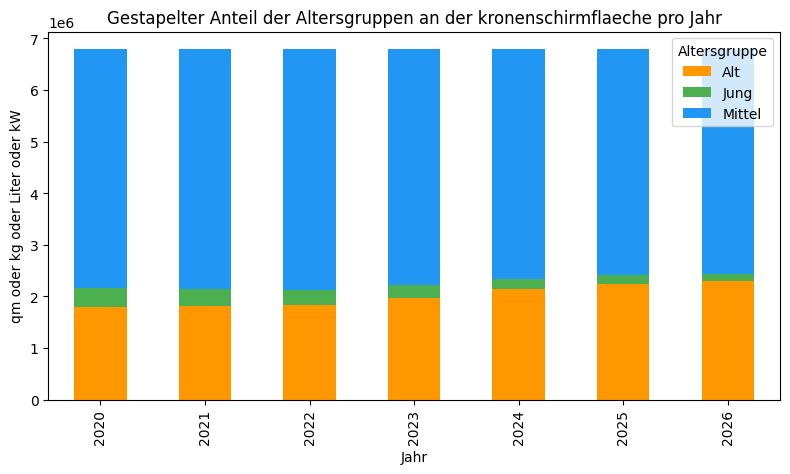

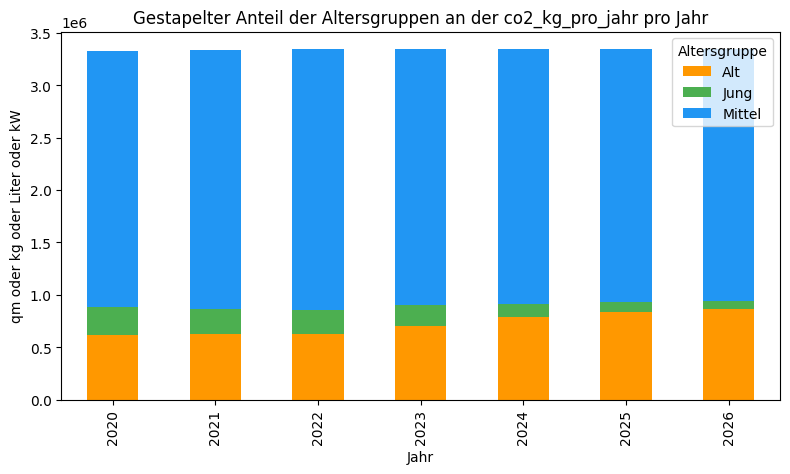

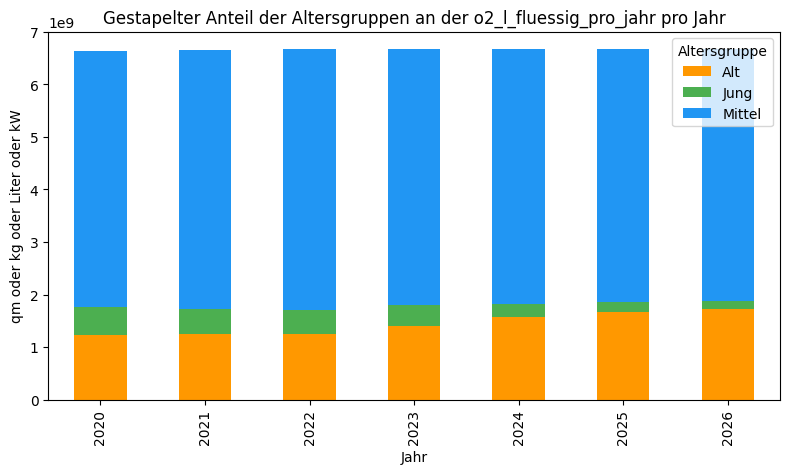

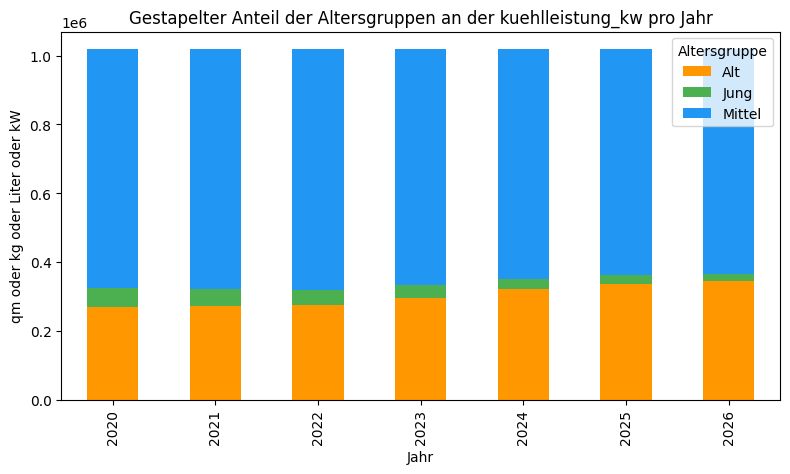

In [9]:

def plot_stacked_bar(df, MYVAL):
    pivot_plot = df.pivot(index="jahr", columns="gruppe", values=MYVAL)

    colors = {"Jung": "#4CAF50", "Mittel": "#2196F3", "Alt": "#FF9800"}

    ax = pivot_plot.plot(
        kind="bar",
        stacked=True,
        color=[colors.get(col, "#888888") for col in pivot_plot.columns],
        figsize=(8, 5),
    )

    ax.set_xlabel("Jahr")
    ax.set_ylabel("qm oder kg oder Liter oder kW")
    ax.set_title(f"Gestapelter Anteil der Altersgruppen an der {MYVAL} pro Jahr")
    #ax.set_ylim(0, 100)
    ax.legend(title="Altersgruppe")
    plt.tight_layout()


plot_stacked_bar(slider_df, "kronenschirmflaeche")
plot_stacked_bar(slider_df, "co2_kg_pro_jahr")
plot_stacked_bar(slider_df, "o2_l_fluessig_pro_jahr")
plot_stacked_bar(slider_df, "kuehlleistung_kw")




In [ ]:
# DATEINAME;RAUM;QUELLE_INSTITUTION;THEMENBEREICH;MERKMAL;ZEIT;WERT;WERTEEINHEIT
# verkehrsmittelwahl-zeitreihe;Münster, Gesamtstadt;Stadt Münster - Amt für Mobilität und Tiefbau;4;Wege/Tag - Kfz;1982;39,20;%
# verkehrsmittelwahl-zeitreihe;Münster, Gesamtstadt;Stadt Münster - Amt für Mobilität und Tiefbau;4;Wege/Tag - ÖV;1982;6,60;%

output_df = pd.DataFrame(columns=["DATEINAME", "RAUM", "QUELLE_INSTITUTION", "THEMENBEREICH", "MERKMAL", "ZEIT", "WERT", "WERTEEINHEIT"])

fields = {
    "kronenschirmflaeche": ["Kronenschirmfläche", "qm"],
    "co2_kg_pro_jahr": ["CO2 Bindung", "kg"],
    "o2_l_fluessig_pro_jahr": ["O2 Flüssig pro Jahr", "Liter"],
    "kuehlleistung_kw": ["Kühlleistung", "kW"]
}

themenbereich = 670
for field in fields:
    themenbereich= themenbereich + 1
    for index, row in slider_df.iterrows():
        output_df = output_df._append({
            "DATEINAME": f"b-{field.replace('_','-')}",
            "RAUM": "Münster",
            "QUELLE_INSTITUTION": "Grünflächenamt",
            "THEMENBEREICH": themenbereich,
            "MERKMAL": f"{row['gruppe']} - {fields[field][0]}",
            "ZEIT": row['jahr'],
            "WERT": row[field],
            "WERTEEINHEIT": fields[field][1]
        }, ignore_index=True)

for pfl in pflanzungen:
    output_df = output_df._append({
        "DATEINAME": "b-pflanzungen",
        "RAUM": "Münster",
        "QUELLE_INSTITUTION": "Grünflächenamt",
        "THEMENBEREICH": 676,
        "MERKMAL": "Pflanzungen",
        "ZEIT": pfl,
        "WERT": pflanzungen[pfl],
        "WERTEEINHEIT": "Anzahl"
    }, ignore_index=True)

output_df.to_csv("data/klimadashboard-baeume.csv", index=False)


C:\Users\wernerth\AppData\Local\Temp\ipykernel_24480\1167042746.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_df = output_df._append({
